##**Business Problem -**

As a marketing agency, our primary Objective is to maximize the return on investment (ROI) for our clients' advertising campaigns. We have conducted two ad
campaigns, one on Facebook and the other on AdWords, and we need to determine which platform yields better results in terms of clicks, conversions, and overall
cost-effectiveness. By identifying the most effective platform, we can allocate our resources efficiently and optimize our advertising strategies to deliver better
outcomes for our clients.


##**Research Question -**

Which ad platform is more effective in terms of conversions, clicks, and overall cost-effectiveness?

###**Importing Libraries -**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')

###**Data Description -**

The dataset comprises a collection of data comparing the performance of two separate ad campaigns conducted throughout the year 2019. Specifically, the data
covers a Facebook Ad campaign and an AdWords Ad campaign. For each day of the year 2019, there is a corresponding row in the dataset, resulting in a total Of 365 lines Of campaign data to analyze. The dataset includes various performance metrics for each ad campaign, providing insights into their effectiveness and efficiency over time.

####**Key features included in the dataset are as follows:**

• Date: The date corresponding to each row of campaign data, ranging from January 1st, 2019, to December 31st, 2019.

• Ad Views: The number Of times the ad was Viewed.

• Ad Clicks: The number Of Clicks received on the ad.

• Ad Conversions: The number of conversions resulting from the ad.

• Cost per Ad: The cost associated with running the Facebook ad campaign.

• Click-Through Rate (CTR): The ratio of clicks to views, indicating the effectiveness of the ad in generating clicks.

• Conversion Rate: The ratio of conversions to clicks, reflecting the effectiveness of ad in driving desired actions.

• Cost per Click (CPC): The average cost incurred per click on the ad.

In [4]:
#loading the dataset -
df= pd.read_csv('/content/sample_data/Marketing_Campaign.csv')

In [5]:
# data overview -
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook CTR,Facebook Conversion Rate,Facebook CPC,AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords CTR,AdWords Conversion Rate,AdWords CPC
0,2019-01-01,FB_Lead_2019,43277,401,186,1011,0.009266,46.38%,2.521197,AW_Sales_2021,20936,60,20,1312,0.002866,33.33%,21.866667
1,2019-01-02,FB_Remarketing_2021,49609,180,88,1534,0.003628,48.89%,8.522222,AW_Brand_2019,24184,386,150,2073,0.015961,38.86%,5.370466
2,2019-01-03,FB_Sales_2021,44640,165,16,217,0.003696,9.70%,1.315152,AW_Lead_2021,6065,1092,354,2722,0.180049,32.42%,2.492674
3,2019-01-04,FB_Brand_2020,25896,368,70,260,0.014211,19.02%,0.706522,AW_Sales_2020,27978,50,13,1637,0.001787,26.00%,32.740000
4,2019-01-05,FB_Remarketing_2021,21729,24,1,2289,0.001105,4.17%,95.375000,AW_Sales_2021,18440,455,57,2375,0.024675,12.53%,5.219780


In [6]:
# rows and columns count of the dataset -
df.shape

(100000, 17)

In [7]:
# datatypes of the column -
df.dtypes

,0
Date,object
Facebook Ad Campaign,object
Facebook Ad Views,int64
Facebook Ad Clicks,int64
Facebook Ad Conversions,int64
Cost per Facebook Ad,int64
Facebook CTR,float64
Facebook Conversion Rate,object
Facebook CPC,float64
AdWords Ad Campaign,object


In [11]:
# converting date to datetime -
df['Date']= pd.to_datetime(df['Date'])

In [12]:
# descriptive stats of the camapigns -
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook CTR,Facebook CPC,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords CTR,AdWords CPC
count,100000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2021-06-28 06:45:00,25300.760600,602.23338,150.530260,1514.508400,0.056278,7.040008,30260.865800,754.953030,150.836760,1770.414610,0.061346,6.811280
min,2019-01-01 00:00:00,500.000000,5.00000,1.000000,30.000000,0.000100,0.026362,500.000000,5.000000,1.000000,40.000000,0.000084,0.027406
25%,2020-03-30 00:00:00,12910.750000,304.00000,42.000000,772.000000,0.012046,1.283826,15424.750000,382.000000,42.000000,907.000000,0.012593,1.203978
50%,2021-06-28 00:00:00,25390.500000,603.00000,113.000000,1520.000000,0.023807,2.509119,30307.500000,755.000000,112.000000,1768.000000,0.024920,2.343393
75%,2022-09-25 00:00:00,37707.000000,900.00000,230.000000,2253.000000,0.046631,4.983498,45072.000000,1131.250000,230.000000,2635.000000,0.049102,4.639344
max,2023-12-30 00:00:00,50000.000000,1200.00000,599.000000,3000.000000,2.353175,598.000000,60000.000000,1500.000000,598.000000,3500.000000,2.685185,684.800000
std,NaN,14304.779442,344.85277,131.675081,857.028119,0.129006,22.366993,17191.301576,432.030596,132.414556,999.085631,0.148941,23.645654


###**Comparing Campaigns Performance -**

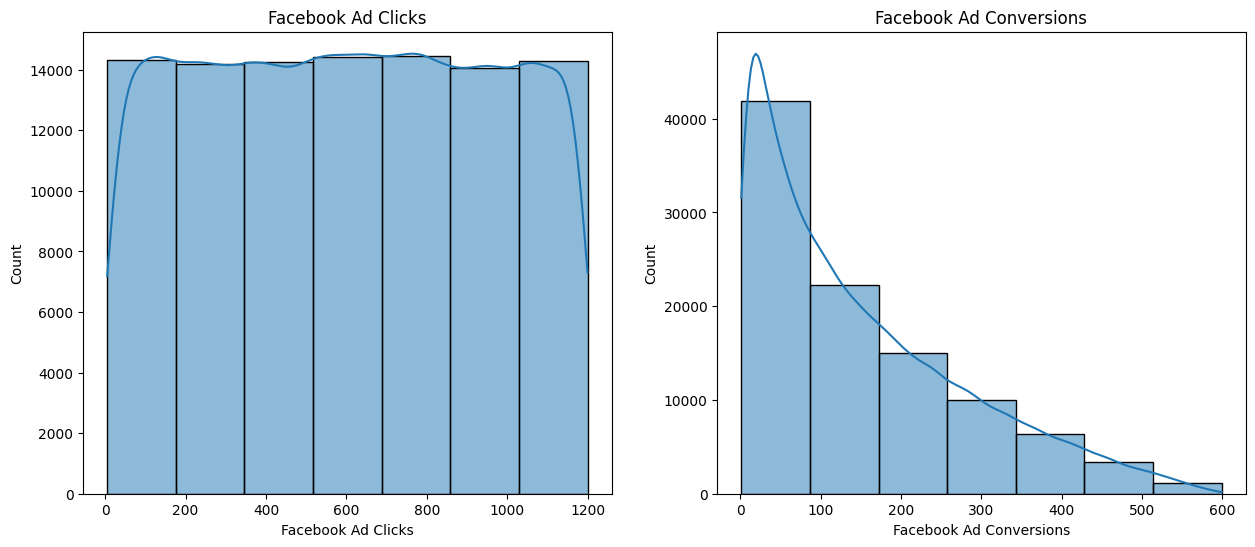

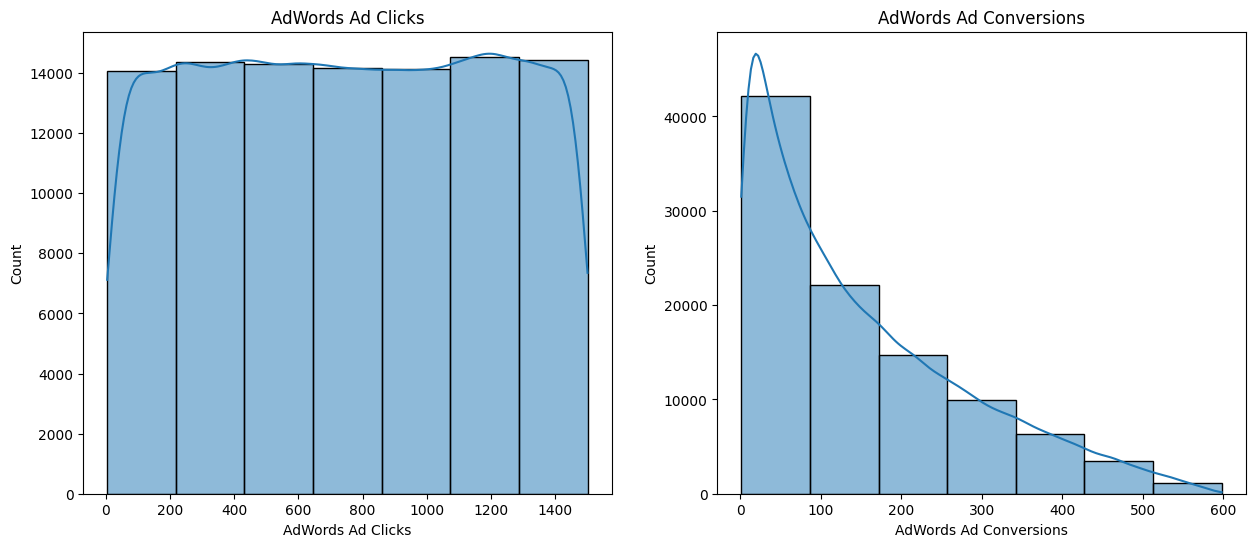

In [18]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title( 'Facebook Ad Clicks')
sns.histplot(df['Facebook Ad Clicks'], bins=7, edgecolor= 'k', kde=True)
plt.subplot(1,2,2)
plt.title( 'Facebook Ad Conversions')
sns.histplot(df['Facebook Ad Conversions'], bins=7, edgecolor = 'k', kde=True)
plt.show()

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title( 'AdWords Ad Clicks')
sns.histplot(df['AdWords Ad Clicks'], bins=7, edgecolor= 'k', kde=True)
plt.subplot(1,2,2)
plt.title( 'AdWords Ad Conversions')
sns.histplot(df['AdWords Ad Conversions'], bins=7, edgecolor = 'k', kde=True)
plt.show()

The histogram of Facebook Ad Clicks shows a fairly even distribution, indicating that click values are spread across different ranges.

However, the Facebook Ad Conversions histogram is positively skewed, with most conversion values concentrated in the lower range and fewer observations at higher values.

This suggests that lower conversion counts occur more frequently, while higher conversion counts are relatively rare.

###**How frequently do we Observe days with high numbers of conversions compared to days with low numbers of conversions? -**

In [23]:
# creating function to calculate the category for the conversions-
def create_conversion_category(conversion_col):
    category = []
    for conversion in df[conversion_col]:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6 - 10')
        elif 11 <= conversion < 16:
            category.append('10 - 15')
        else:
            category.append('more than 15')
    return category

# applying function of different campaign's conversions
df [ 'Facebook Conversion Category' ] = create_conversion_category('Facebook Ad Conversions')
df [ 'AdWords Conversion Category' ] =create_conversion_category ( 'AdWords Ad Conversions')

In [25]:
df[['Facebook Ad Conversions','Facebook Conversion Category','AdWords Ad Conversions','AdWords Conversion Category']].head()

,Facebook Ad Conversions,Facebook Conversion Category,AdWords Ad Conversions,AdWords Conversion Category
0,186,more than 15,20,more than 15
1,88,more than 15,150,more than 15
2,16,more than 15,354,more than 15
3,70,more than 15,13,10 - 15
4,1,less than 6,57,more than 15


In [26]:
df['Facebook Conversion Category'].value_counts()

,count
Facebook Conversion Category,
more than 15,88634
less than 6,4434
6 - 10,3645
10 - 15,3287


In [35]:
facebook = df['Facebook Conversion Category'].value_counts().reset_index()
facebook.columns = ['Category', 'Count']

In [29]:
facebook

,Facebook Conversion Category,count
0,more than 15,88634
1,less than 6,4434
2,6 - 10,3645
3,10 - 15,3287


In [42]:
df['AdWords Conversion Rate'].value_counts()

,count
AdWords Conversion Rate,
33.33%,330
25.00%,237
20.00%,223
16.67%,177
40.00%,168
...,...
28.58%,5
24.97%,4
39.99%,3


In [37]:
adwords = df['AdWords Conversion Category'].value_counts().reset_index()
adwords.columns = ['Category', 'Count']
adwords

,Category,Count
0,more than 15,88641
1,less than 6,4510
2,6 - 10,3607
3,10 - 15,3242


In [38]:
category_df=pd.merge(facebook,adwords,on='Category',how='outer', suffixes=('_facebook', '_adwords')).fillna(0)
category_df

,Category,Count_facebook,Count_adwords
0,10 - 15,3287,3242
1,6 - 10,3645,3607
2,less than 6,4434,4510
3,more than 15,88634,88641


In [41]:
category_df = category_df.iloc[[3,1,0,2]]
category_df

,Category,Count_facebook,Count_adwords
2,less than 6,4434,4510
1,6 - 10,3645,3607
3,more than 15,88634,88641
0,10 - 15,3287,3242


In [46]:
x_axis=np.arange(len(category_df))
x_axis

array([0, 1, 2, 3])

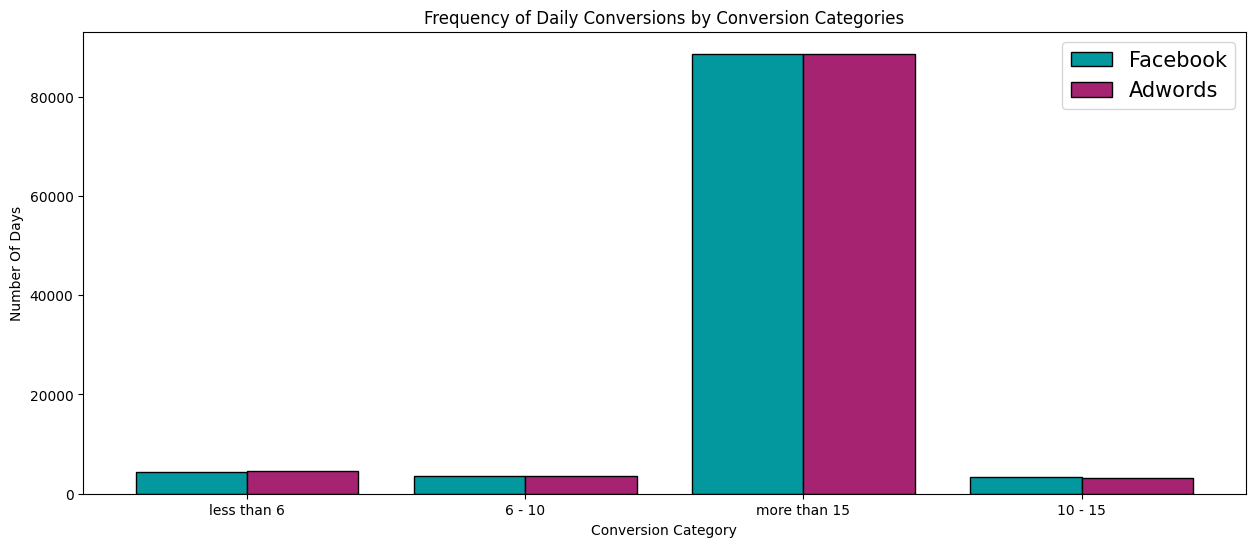

In [45]:
x_axis=np.arange(len(category_df))
plt.figure(figsize=(15,6))
plt.bar(x_axis-0.2,category_df['Count_facebook'],0.4,label='Facebook',color='#03989E',linewidth=1, edgecolor='k')
plt.bar(x_axis+0.2,category_df['Count_adwords'],0.4,label='Adwords',color='#A62372',linewidth=1, edgecolor='k')

plt.xticks(x_axis,category_df['Category'])
plt.xlabel('Conversion Category')
plt.ylabel('Number Of Days')
plt.title('Frequency of Daily Conversions by Conversion Categories')
plt.legend(fontsize=15)
plt.show()

• Both Facebook and AdWords recorded the highest number of days in the "more than 15" conversion category, indicating strong conversion performance.

• Lower conversion categories (less than 6, 6–10, and 10–15) were observed less frequently in both campaigns.

• Overall, both campaigns show a similar conversion pattern with only minor variations.

####**Do more clicks on the ad really lead to more sales? -**

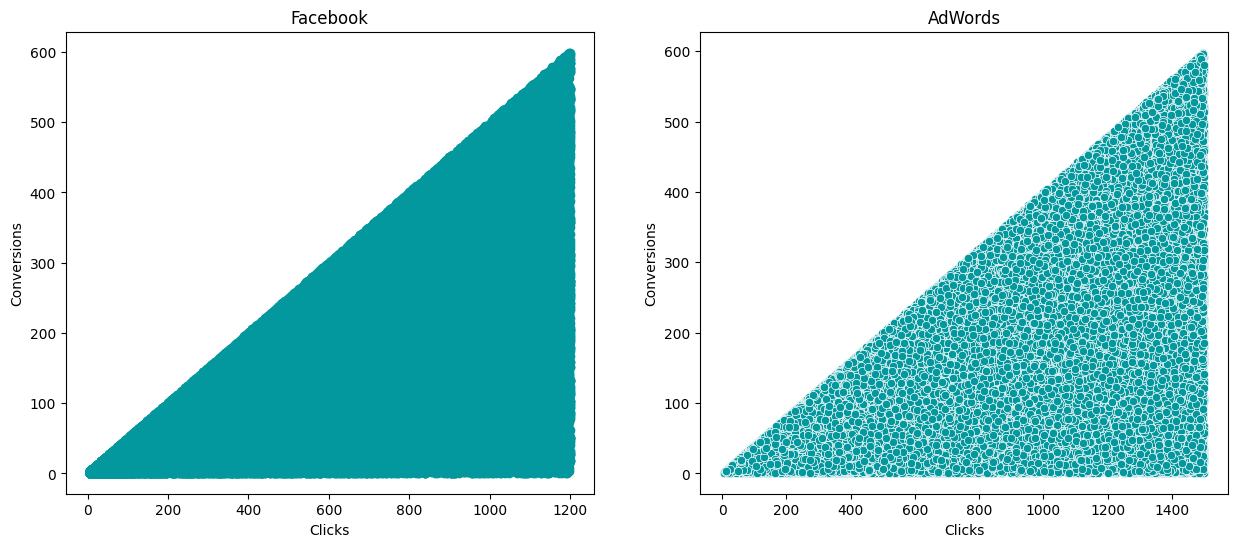

In [48]:
from seaborn.relational import scatterplot
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.title( 'Facebook')
plt.scatter(x=df['Facebook Ad Clicks'],y= df['Facebook Ad Conversions'],color= '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.subplot(1,2,2)
plt.title( 'AdWords')
sns.scatterplot(x=df['AdWords Ad Clicks'],y= df['AdWords Ad Conversions'],color= '#03989E')
plt.xlabel('Clicks')
plt.ylabel('Conversions')
plt.show()

In [50]:
facebook_corr=df[['Facebook Ad Conversions','Facebook Ad Clicks']].corr()
facebook_corr

,Facebook Ad Conversions,Facebook Ad Clicks
Facebook Ad Conversions,1.000000,0.651133
Facebook Ad Clicks,0.651133,1.000000


In [52]:
adwords_corr=df[['AdWords Ad Conversions','AdWords Ad Clicks']].corr()
adwords_corr

,AdWords Ad Conversions,AdWords Ad Clicks
AdWords Ad Conversions,1.000000,0.650792
AdWords Ad Clicks,0.650792,1.000000


In [54]:
print('Correlation Coeff \n --------------')
print(f"Facebook: {round(facebook_corr.values[0,1],2)}")
print(f"AdWords: {round(adwords_corr.values[0,1],2)}")

Correlation Coeff 
 --------------
Facebook: 0.65
AdWords: 0.65


• A correlation coefficient of 0.65 indicates a moderately strong positive linear relationship between clicks on Facebook ads and sales. This suggests that as the number of clicks on Facebook ads increases, sales also tend to increase.

• This positive correlation suggests that Facebook ads are effective in driving sales, although the relationship is moderate rather than extremely strong.

• The correlation between clicks on Facebook ads and sales indicates that optimizing Facebook advertising campaigns and increasing quality engagement may help improve sales performance.

• A correlation coefficient of 0.65 indicates a moderately strong positive linear relationship between clicks on AdWords ads and sales. This suggests that as AdWords ad clicks increase, sales also tend to increase.

• Since both Facebook and AdWords have the same correlation coefficient (0.65), both advertising platforms show a similar positive impact on sales, indicating that each can contribute effectively to business growth.

###**Hypothesis Testing -**

**Hypothesis:** Advertising on Facebook will result in a greater of conversions compared to advertising on AdWords.

**Null Hypothesis (HO):** There is no difference in the number of conversions between Facebook and AdWords, or the number of conversions from AdWords is greater than or equal to those from Facebook.

HO: u_FacebOOk s u_AdWords

**Alternate Hypothesis (HI):** The number Of conversions Facebook is greater than the number of conversions from AdWords.

H1: u_Facebook >u_AdWords

In [55]:
print('Mean Conversion \n --------------')
print(f"Facebook: {round(df['Facebook Ad Conversions'].mean(),2)}")
print(f"AdWords: {round(df['AdWords Ad Conversions'].mean(),2)}")

t_stats, p_value = st.ttest_ind(a=df['Facebook Ad Conversions'], b=df['AdWords Ad Conversions'], equal_var= False)
print('\nT statistic', t_stats, '\np-value', p_value)

# comparing the p-value with the significance of 5% or 0.05
if p_value < 0.05:
    print('\np-value is greater than significance value, Reject the null hypothesis')
else:
    print('\np-value is less than significance value, Fail to reject the null hypothesis')


Mean Conversion 
 --------------
Facebook: 150.53
AdWords: 150.84

T statistic -0.5190299450859179 
p-value 0.6037404336166815

p-value is less than significance value, Fail to reject the null hypothesis


• The mean conversion for Facebook ads is 150.53, while the mean conversion for AdWords ads is 150.84.

• The p-value (0.6037) is greater than the significance level (0.05), indicating that the difference between the two mean conversions is not statistically significant.

• Therefore, we fail to reject the null hypothesis, suggesting that Facebook and AdWords have similar average conversion performance.

• This indicates that neither platform significantly outperforms the other in terms of mean conversions based on the given dataset.


###**Regression Analysis -**

What will happen when I do go with the Facebook Ad? How many facebook ad conversions can I expect given a certain number of facebook ad clicks?

In [58]:
# independent variable -
X=df[['Facebook Ad Clicks']]

# dependent variable -
y=df[['Facebook Ad Conversions']]

# initializing & fitting Linear Regression Model -
reg_model=LinearRegression()
reg_model.fit(X,y)
prediction= reg_model.predict(X)

# model evaluation
r2=r2_score(y,prediction)*100
mse=mean_squared_error(y,prediction)
print('Accuracy(R2 Score):',round(r2,2))
print('Mean Squared Error: ',round(mse,2))

Accuracy(R2 Score): 42.4
Mean Squared Error:  9987.22


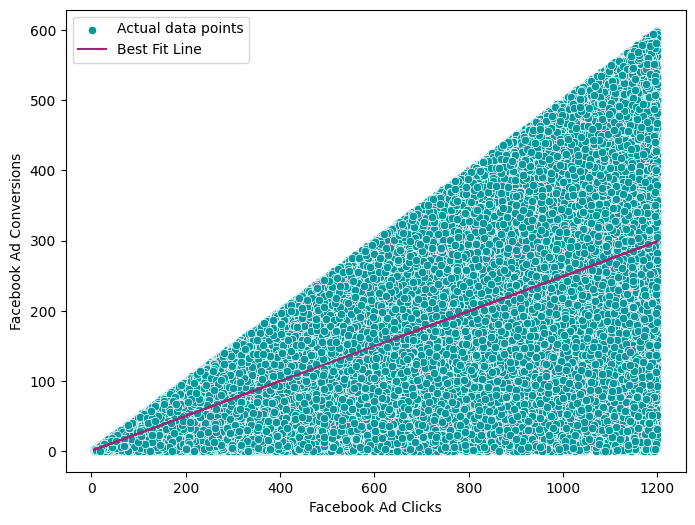

In [60]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Facebook Ad Clicks'],y= df['Facebook Ad Conversions'],color= '#03989E',label= "Actual data points")
plt.plot(df['Facebook Ad Clicks'],prediction,color= '#A62372',label= "Best Fit Line")
plt.legend()
plt.show()

In [62]:
print(f'For {50} clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0],2)} conversions')
print(f'For {80} clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0],2)} conversions')

For 50 clicks, Expected Conversion : 13.23 conversions
For 80 clicks, Expected Conversion : 20.69 conversions


• The model has a moderate predictive power, with an R² score of 42.4%. This indicates that Facebook Ad Clicks explain a moderate portion of the variation in Facebook Ad Conversions, but other factors may also influence conversions.

• The Linear Regression model can still provide useful insights for estimating Facebook Ad Conversions. However, its predictions should be used along with other campaign metrics for better decision-making and campaign optimization.

• For example, the model can be used to estimate the expected number of Facebook Ad Conversions based on a given number of Facebook Ad Clicks, helping businesses with campaign planning, budget allocation, and performance evaluation.

###**Analyzing Facebook Campaign metrics over time-**


In [64]:
#cleaning data (removing unwanted symbols from the columns and converting then to numerical columns)
# Cleaning 'Facebook Conversion Rate'
df['Facebook Conversion Rate'] = df['Facebook Conversion Rate'].apply(lambda x: float(x[:-1]))

# Cleaning 'AdWords Conversion Rate'
df['AdWords Conversion Rate'] = df['AdWords Conversion Rate'].apply(lambda x: float(x[:-1]))

In [66]:
#filtering for facebook campaign -
df= df [['Date', 'Facebook Ad Views', 'Facebook Ad Clicks', 'Facebook Ad Conversions', 'Cost per Facebook Ad', 'Facebook CTR',
'Facebook Conversion Rate', 'Facebook CPC']]

####**At what times Of the month Or days Of the week do we observe the conversions?**

In [67]:
# extracting month & weekday from the Date column -
df['Month']=df['Date'].dt.month
df['Weekday']=df['Date'].dt.day_name()

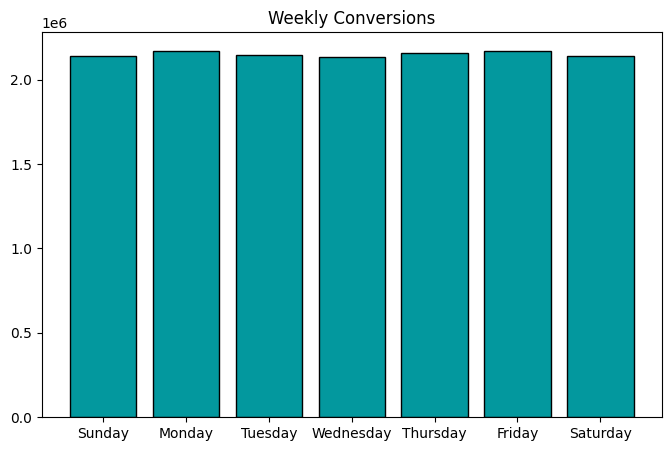

In [71]:
plt.figure(figsize=(8,5))
plt.title('Weekly Conversions')
week_names= ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
weekly_conversion_raw = df.groupby('Weekday')[['Facebook Ad Conversions']].sum()
weekly_conversion = weekly_conversion_raw.reindex(week_names)
plt.bar(week_names, weekly_conversion['Facebook Ad Conversions'],color='#03989E', edgecolor='k')
plt.show()

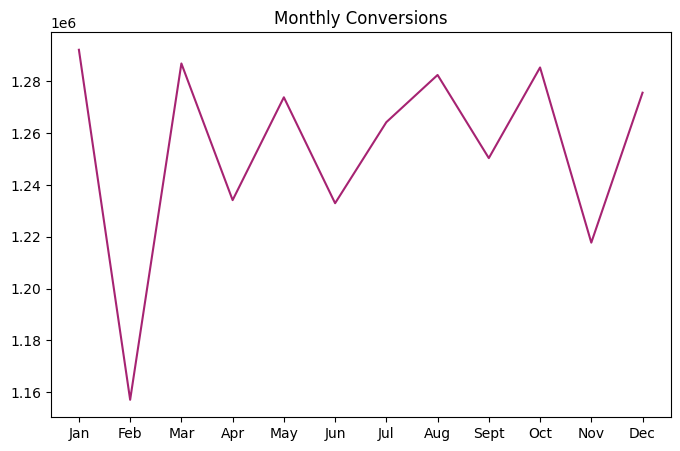

In [74]:
plt.figure(figsize=(8,5))
plt.title('Monthly Conversions')
month_names= ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sept','Oct','Nov','Dec']
monthly_conversion = df.groupby('Month')[['Facebook Ad Conversions']].sum()
plt.plot(month_names, monthly_conversion['Facebook Ad Conversions'], color='#A62372')
plt.show()

• Across the weekdays over a year, the total number of conversions remains relatively stable, indicating consistent user engagement throughout the week. Monday records the highest number of conversions, while Saturday has the lowest.

-> The differences between weekdays are minimal, suggesting that conversion performance remains fairly balanced across the week.

• Examining the monthly trend in conversions reveals an overall upward trajectory, indicating a general increase in conversions over time. However, certain months stand out with variations in conversion rates.

-> February, April, May, June, August. and November experience a decline in conversions compared to neighboring months. These periods of decreased con-version rates could be influenced by factors such as seasonal fluctuations, changes in consumer behavior, or adjustments in marketing strategies.

###**How does the Cost Per Conversion (CPC) trend over time? -**

**Cost Per Conversion (CPC):** This metric is used to evaluate the cost effectiveness and profitability Of an online advertising campaign. This metric helps marketers understand how much they are spending to obtain each conversion, allowing them to optimize their spending and targeting strategies effectively.


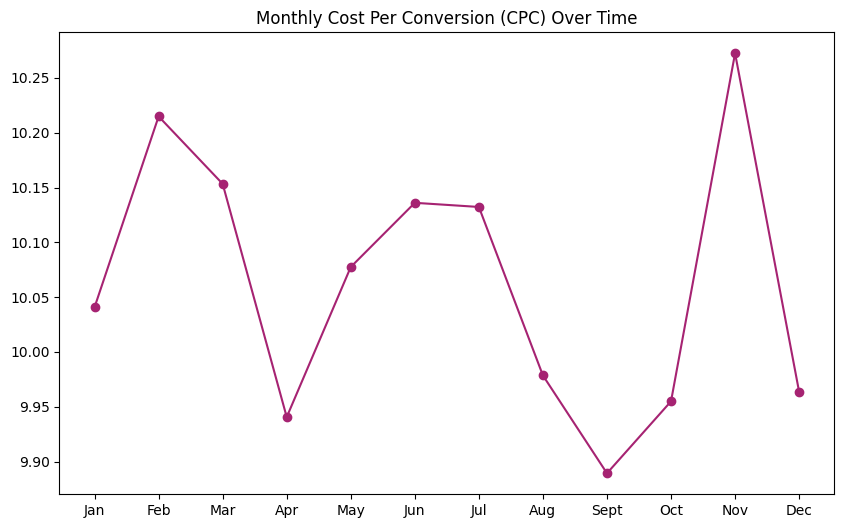

In [76]:
plt.figure(figsize=(10, 6))
plt.title('Monthly Cost Per Conversion (CPC) Over Time')
monthly_df= df.groupby('Month')[['Facebook Ad Conversions', 'Cost per Facebook Ad']].sum()
monthly_df['Cost per Conversion']= monthly_df['Cost per Facebook Ad'] / monthly_df['Facebook Ad Conversions']
plt.plot(month_names, monthly_df['Cost per Conversion'], '-o',color='#A62372')

• The CPC trend over the 12-month period shows moderate fluctuations but overall remains within a relatively stable range.

• September has the lowest CPC value, indicating potentially more cost-effective advertising or improved conversion efficiency during this month.

• November has the highest CPC value, suggesting that advertising costs were relatively higher compared to the other months.

• Lower CPC values observed in September (and comparatively lower values in April and October) may indicate periods of better advertising performance or more favorable market conditions.

• Consider allocating a larger share of the advertising budget to months with historically lower CPC values, particularly September, to improve overall return on investment (ROI).

###**Is there a long-term equilibrium relationship between advertising spend and conversion rates that suggests a stable, proportional impact Of budget changes on conversions over time?-**

In [78]:
score,p_value,_=coint(df['Facebook Ad Conversions'],df['Cost per Facebook Ad'])
print('Cointegration test - score:' , score)
print('P-value:' , p_value)
if p_value < 0.05:
    print('\np-value is less than significance value, Reject the null hypothesis')
else:
    print('\np-value is greater than significance value, Accpet the null hypothesis')

Cointegration test - score: -224.67741479405422
P-value: 0.0

p-value is less than significance value, Reject the null hypothesis


• Since the p-value is significantly lower than the chosen significance level (0.05), we reject the null hypothesis. This indicates that there is a long-term equilibrium relationship between Facebook advertising cost and Facebook ad conversions.

• This suggests that changes in Facebook advertising cost are associated with corresponding changes in conversions over time. Businesses can use this relationship to optimize advertising budgets, improve campaign performance, and maximize conversions while maintaining cost efficiency.